In [1]:
import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt
import torch

In [15]:
# If CUDA is available, show more details
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("PyTorch is using CPU only")

PyTorch is using CPU only


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [6]:
def surface_code_circuit(p, d): # physical error rate, distance
  return stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=d,
    distance=d,
    after_clifford_depolarization=p,
    after_reset_flip_probability=p,
    before_measure_flip_probability=p,
    before_round_data_depolarization=p)

def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> int:
  # Sample the circuit.
  sampler = circuit.compile_detector_sampler()
  detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

  # Configure a decoder using the circuit.
  detector_error_model = circuit.detector_error_model(decompose_errors=True)
  matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

  # Run the decoder.
  predictions = matcher.decode_batch(detection_events)

  # basically compare predictions with observable_flips (what we should have measured)

  # Count the mistakes.
  num_errors = 0
  for shot in range(num_shots):
    actual_for_shot = observable_flips[shot]
    predicted_for_shot = predictions[shot]
    if not np.array_equal(actual_for_shot, predicted_for_shot):
        num_errors += 1
  return num_errors

def ler_mwpm(p, d): # logical error rate, minimum weight perfect matching
  num_shots = 100000
  circuit = surface_code_circuit(p, d)
  num_errors = count_logical_errors(circuit, num_shots) 

  return num_errors / num_shots

def plot_mwpm(): 
  num_shots = 100000
  for d in [3, 5, 7]:
    xs = []
    ys = []
    yerrs = []
    for noise in np.linspace(0.001, 0.008, 8):
      ler = ler_mwpm(noise, d)
      xs.append(noise)
      ys.append(ler)
      yerrs.append(np.sqrt(ler * (1 - ler) / num_shots))
  plt.loglog()
  plt.xlabel("physical error rate")
  plt.ylabel("logical error rate per shot")
  plt.legend()
  plt.show()


after_clifford: after every operation e.g. H gate, you will apply X, Y, Z with probability p/3 each <br/>
after_reset_flip: after you do a reset (you think you're resetted to 0 but reset to 1 with probability p) <br/>
before_measure_flip: you should measuring a 0 but with p you're measuring a 1 <br/>
before_round_data_depolarization: we apply the same general error - errors no operation (interaction with the environment - decohere) - idling error

C:\Users\Bill\AppData\Local\Temp\ipykernel_22380\1385133306.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


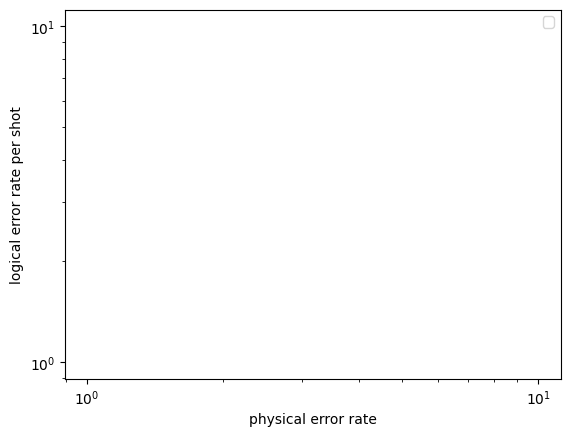

In [17]:
plot_mwpm()

In [ ]:
# do we need to train a model for each physical error rate or train at one physical error rate
# and then extrapolate at different physical error rates

# extrapolating distance: more difficult input shape
# evaluate the inference speed of the model 
# data for distances 

In [8]:
train_size = 10**7 
p = 0.005
d = 5

circuit = surface_code_circuit(p, d)
sampler = circuit.compile_detector_sampler()
detections, flips = sampler.sample(shots=train_size, separate_observables=True)
# detections is input into decoder 

num_input = detections.shape[1]

detections = detections.astype(int) * 2 -1 # converts to +1 and -1 
detections, flips = torch.Tensor(detections).to(device), torch.Tensor(flips.astype(int).flatten()).to(device)

In [19]:
detections[0].shape

torch.Size([120])

In [14]:
1 - ler_mwpm(p, 5)

0.98603

In [9]:
from torch import nn

In [10]:
decoder = nn.Sequential(
  nn.Linear(num_input, 256),
  nn.SiLU(),
  nn.Linear(256, 512),
  nn.SiLU(),
  nn.Linear(512, 1024),
  nn.SiLU(),
  nn.Linear(1024, 1),
  nn.Sigmoid()
).to(device)
loss_fn = nn.BCELoss() # inverse of accuracy

In [12]:
# Create optimizer - if this fails with _utils error, run diagnostic cells above and reinstall PyTorch
optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-3) # tells you how to train 
# important here is lr, it cannot be too high, you are going to start missing out features, cannot be too slow, you are going to take forever

Seeing whether you can train higher distance models and the problem if you cannot

In [13]:
from tqdm.auto import *

def train_loop(measurements, flips, bs=200):
  decoder.train()
  running_avg = 0
  with trange(train_size//bs) as pbar:
    for batch in pbar:
      X = measurements[batch*bs:(batch+1)*bs]
      y = flips[batch*bs:(batch+1)*bs][:,None]
      #pred = decoder(X.reshape((-1, 5*12)))
      pred = decoder(X)
      loss = loss_fn(pred, y)
      acc = torch.mean(((pred>0.5) == y).float())
      running_avg = acc * 0.01 + running_avg*0.99 if running_avg != 0 else acc
      # Backpropagation
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
      if batch % 100 == 0:
        pbar.set_description(f'{running_avg:>4f} {loss:.4f}')

C:\Users\Bill\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
train_loop(detections, flips, bs=256)
train_loop(detections, flips, bs=8000) # model remmebers the first trian_loop, trains on top

0.983165 0.0420: 100%|██████████| 1250/1250 [00:49<00:00, 25.38it/s]


In [ ]:
1 - ler_mwpm(p, d) # accuracy of ler_mwpm, already beat,but iwht larger distances you would need more data to beat

0.98187

In [ ]:
detections.shape

torch.Size([10000000, 24])

In [ ]:
detections

tensor([[-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        ...,
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.]])

In [43]:
c = surface_code_circuit(0, 3)

In [44]:
c.get_detector_coordinates()  # Returns dict mapping detector index → [x, y, ...] coordinates

{0: [0.0, 4.0, 0.0],
 1: [2.0, 2.0, 0.0],
 2: [4.0, 4.0, 0.0],
 3: [6.0, 2.0, 0.0],
 4: [2.0, 0.0, 1.0],
 5: [2.0, 2.0, 1.0],
 6: [4.0, 2.0, 1.0],
 7: [6.0, 2.0, 1.0],
 8: [0.0, 4.0, 1.0],
 9: [2.0, 4.0, 1.0],
 10: [4.0, 4.0, 1.0],
 11: [4.0, 6.0, 1.0],
 12: [2.0, 0.0, 2.0],
 13: [2.0, 2.0, 2.0],
 14: [4.0, 2.0, 2.0],
 15: [6.0, 2.0, 2.0],
 16: [0.0, 4.0, 2.0],
 17: [2.0, 4.0, 2.0],
 18: [4.0, 4.0, 2.0],
 19: [4.0, 6.0, 2.0],
 20: [0.0, 4.0, 3.0],
 21: [2.0, 2.0, 3.0],
 22: [4.0, 4.0, 3.0],
 23: [6.0, 2.0, 3.0]}

In [39]:
svg_diagram = c.diagram("timeline-svg")

with open("timeline_diagram_no_errors_3.svg", "w") as f:
    f.write(str(svg_diagram))
print("Saved to timeline_diagram_no_errors_3.svg")

Saved to timeline_diagram_no_errors_3.svg
